In [1]:
import matplotlib.pyplot as plt

# To install the font library required for specific fonts
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf

import matplotlib.font_manager as fm

fm.fontManager.addfont('/content/TimesNewRoman.ttf')
fm.fontManager.addfont('/content/times.ttf')
fm.fontManager.addfont('/content/timesbd.ttf')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

In [3]:
# The model

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
loss_fn = tf.keras.losses.BinaryCrossentropy()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# For the decision boudary

def plot_decision_boundary(model, X, y, epoch):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = model(grid).numpy().reshape(xx.shape)

    plt.figure(figsize=(4,4))
    plt.contourf(xx, yy, preds, levels=[0,0.5,1], colors=['salmon','lightblue'], alpha=0.6)
    plt.contour(xx, yy, preds, levels=[0.5], colors='green', linewidths=2)

    for i in range(len(X)):
        color = 'blue' if y[i][0] == 1 else 'red'
        plt.scatter(X[i][0], X[i][1], c=color, s=100, edgecolors='k', zorder=3)

    plt.title(f"Decision Boundary (Epoch {epoch})")
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.3)
    plt.show()

Epoch 1, Loss: 0.7146


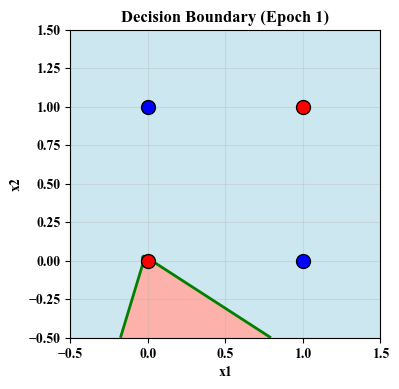

Epoch 500, Loss: 0.1254


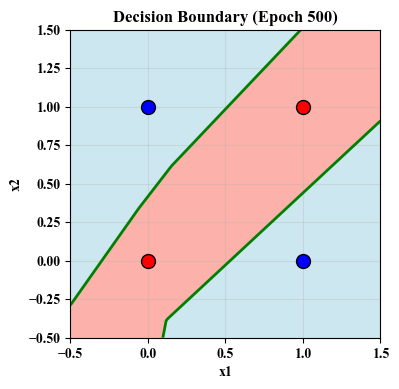

Epoch 1000, Loss: 0.0203


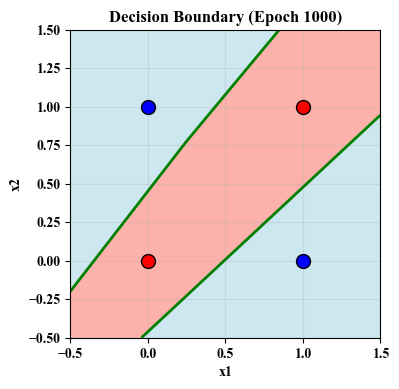

Epoch 1500, Loss: 0.0091


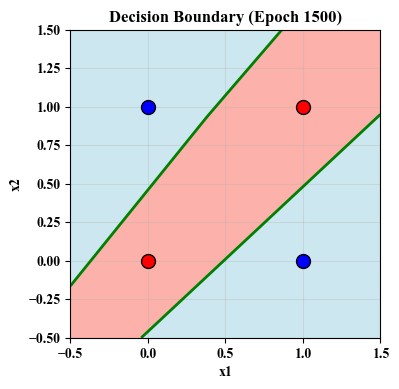

Epoch 2000, Loss: 0.0055


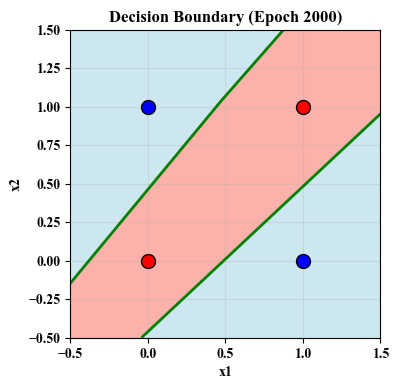

Epoch 2500, Loss: 0.0039


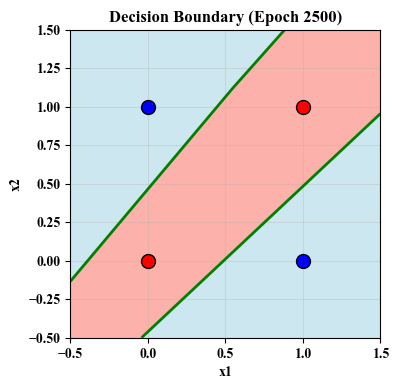

Epoch 3000, Loss: 0.0029


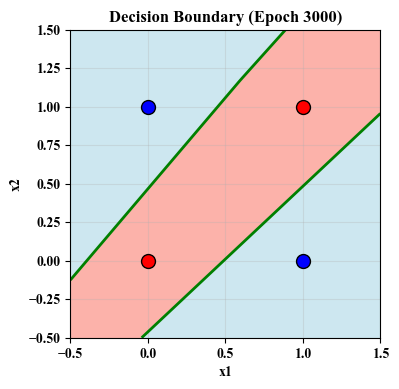

In [5]:
epochs = 3000
plot_every = 500   # <-- change this to control clutter

for epoch in range(1, epochs + 1):
    with tf.GradientTape() as tape:
        predictions = model(X, training=True)
        loss = loss_fn(y, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if epoch % plot_every == 0 or epoch == 1:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")
        plot_decision_boundary(model, X, y, epoch)

In [7]:
print("Final predictions on XOR inputs:")
final_preds = model(X).numpy()
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted: {round(final_preds[i][0])}")

Final predictions on XOR inputs:
Input: [0. 0.], Predicted: 0
Input: [0. 1.], Predicted: 1
Input: [1. 0.], Predicted: 1
Input: [1. 1.], Predicted: 0
